In [1]:
!pip install pennylane pennylane-qiskit torch torchvision

INFO: pip is looking at multiple versions of torch to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of torch to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.1/797.1 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 51.1 MB/s eta 0:

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import pennylane as qml
from pennylane import numpy as np

In [3]:
# 1. Pick the device at the top of your script
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# MNIST data - downscaled......since quantum generators can only handle samll output

transform = transforms.Compose([
    transforms.Resize((4,4)),         # Downscale 28x28 → 4x4
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])

# load the full dataset
dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# LIMIT dataset to first 500 samples
dataset = torch.utils.data.Subset(dataset, range(1000))

# dataloader
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:00<00:00, 131152835.77it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 41286875.88it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:00<00:00, 46677587.50it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 5549236.46it/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [4]:
# defining quantum circuit

n_qubits = 4
#dev = qml.device("default.qubit", wires=n_qubits)
dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch", diff_method="parameter-shift", cache = True)
def quantum_circuit(inputs, weights):

    # Angle encoding
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)

    # Variational layers
    qml.templates.StronglyEntanglingLayers(weights, wires=range(n_qubits))

    # Measurement
    return tuple(qml.expval(qml.PauliZ(i)) for i in range(n_qubits))


In [ ]:
# defining quantum generator

class QuantumGenerator(nn.Module):
    def __init__(self):
        super().__init__()

        # Hardcoded config
        self.latent_dim = 16
        self.n_qubits = 4
        self.n_layers = 2

        # Latent → qubit input
        self.latent_to_qubit = nn.Linear(self.latent_dim, self.n_qubits)

        # Quantum weights for StronglyEntanglingLayers
        self.weights = nn.Parameter(0.01 * torch.randn(self.n_layers, self.n_qubits, 3))

        # Output postprocessing to image shape (16 pixels)
        self.postprocess = nn.Linear(self.n_qubits, 16)

    def forward(self, z):
        outputs = []
        for i in range(z.shape[0]):

            # Map latent vector to qubit inputs
            input_qubit = self.latent_to_qubit(z[i])

            out = quantum_circuit(input_qubit, self.weights)  # tuple of floats

            out_tensor = torch.stack(list(out))  # tensor of shape [n_qubits]

            # Apply quantum circuit (no torch.tensor conversion!)
            #out_tensor = quantum_circuit(input_qubit, self.weights)

            outputs.append(out_tensor)

        # Stack batch of outputs
        q_out = torch.stack(outputs)  # shape: [batch_size, n_qubits]

        # Postprocess to 16-pixel image
        return self.postprocess(q_out)  # shape: [batch_size, 16]

In [ ]:
# classical discriminator

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        '''
        self.model = nn.Sequential(
            #nn.Linear(4, 64),
            nn.Linear(16, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
        '''

        '''
        self.model = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=1, padding=1),  # 4x4 → 4x4
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(32 * 4 * 4, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        '''

        self.model = nn.Sequential(
            nn.Linear(16, 64),  # 24 instead of 16
            nn.LeakyReLU(0.2),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        flat = img.view(img.size(0), -1)
        return self.model(flat)

In [7]:
# models and optimisers

G = QuantumGenerator()
D = Discriminator()

# Weight initialization
def weights_init(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

G.apply(weights_init)
D.apply(weights_init)

# Use the correct loss (no Sigmoid in D)
criterion = nn.BCEWithLogitsLoss()

optimizer_G = optim.Adam(G.parameters(), lr=0.005)
optimizer_D = optim.Adam(D.parameters(), lr=0.0005)

In [10]:
import time
G_losses = []
D_losses = []

In [11]:
# training

# BEFORE LOOP
G = G.to(device)
D = D.to(device)

epochs = 10

for epoch in range(epochs):
    for i, (real_imgs, _) in enumerate(dataloader):

        batch_size = real_imgs.size(0)
        real_imgs = real_imgs.to(device)
        #real_imgs = real_imgs.view(batch_size, -1).to(device)

        #real_labels = torch.ones(batch_size, 1)
        #fake_labels = torch.zeros(batch_size, 1)
        #real_labels = torch.full((batch_size, 1), 0.9)
        #fake_labels = torch.full((batch_size, 1), 0.1)
        real_labels = torch.empty(batch_size, 1).uniform_(0.7, 1.0).to(device)
        fake_labels = torch.empty(batch_size, 1).uniform_(0.0, 0.3).to(device)

        # Train Discriminator
        if i%4 == 0:


          # Train Discriminator
          '''
          z = torch.randn(batch_size, 16).to(device)
          gen_out = G(z).detach()

          # Expand generator output to 4x4 "image"

          fake_imgs = gen_out.view(batch_size, 1, 4, 4)
          #fake_imgs = fake_imgs.repeat(1, 1, 2, 1)  # (batch_size, 4, 2, 2)
          #fake_imgs = fake_imgs[:, :, :, :4]
          #fake_imgs = fake_imgs.reshape(batch_size, 1, 4, 4)
          '''
          z_d = torch.randn(batch_size, 16).to(device)
          gen_out_d = G(z_d).detach()  # detach so D doesn't store gradients


          fake_imgs_d = gen_out_d.view(batch_size, 1, 4, 4)

          # Optional input noise for regularization:

          #fake_imgs = fake_imgs + 0.05 * torch.randn_like(fake_imgs)

          #real_imgs = real_imgs + 0.05 * torch.randn_like(real_imgs)

          fake_imgs_d = fake_imgs_d + 0.05 * torch.randn_like(fake_imgs_d)

          real_imgs_noisy = real_imgs + 0.05 * torch.randn_like(real_imgs)


          D_real = D(real_imgs_noisy)
          D_fake = D(fake_imgs_d)

          D_loss_real = criterion(D_real, real_labels)
          D_loss_fake = criterion(D_fake, fake_labels)
          D_loss = D_loss_real + D_loss_fake

          optimizer_D.zero_grad()
          D_loss.backward()
          optimizer_D.step()
          D_losses.append(D_loss.item())
        else:
          D_losses.append(None)  # dummy value for logging



        # Train Generator

        z_g = torch.randn(batch_size, 16).to(device)

        start = time.time()
        gen_out_g = G(z_g)
        print("Generator forward time:", time.time() - start)
        print(f"Epoch {epoch+1}, Batch {i+1}/{len(dataloader)}")
        '''
        fake_imgs = gen_out.view(batch_size, 1, 4, 4)
        #fake_imgs = fake_imgs.repeat(1, 1, 2, 1)
        #fake_imgs = fake_imgs[:, :, :, :4]
        #fake_imgs = fake_imgs.reshape(batch_size, 1, 4, 4)

        D_fake = D(gen_out)
        G_loss = criterion(D_fake, real_labels)

        optimizer_G.zero_grad()
        G_loss.backward()
        optimizer_G.step()
        '''
        fake_imgs_g = gen_out_g.view(batch_size, 1, 4, 4)
        D_fake_g = D(fake_imgs_g)

        G_loss = criterion(D_fake_g, real_labels)

        optimizer_G.zero_grad()
        G_loss.backward()
        optimizer_G.step()
        # save losses

        G_losses.append(G_loss.item())

    print(f"Epoch [{epoch+1}/{epochs}] D Loss: {D_loss.item():.4f} G Loss: {G_loss.item():.4f}")


Generator forward time: 0.2384319305419922
Epoch 1, Batch 1/125
Generator forward time: 0.04912829399108887
Epoch 1, Batch 2/125
Generator forward time: 0.06380772590637207
Epoch 1, Batch 3/125
Generator forward time: 0.04964280128479004
Epoch 1, Batch 4/125
Generator forward time: 0.04839634895324707
Epoch 1, Batch 5/125
Generator forward time: 0.05165386199951172
Epoch 1, Batch 6/125
Generator forward time: 0.05276203155517578
Epoch 1, Batch 7/125
Generator forward time: 0.06902313232421875
Epoch 1, Batch 8/125
Generator forward time: 0.04913735389709473
Epoch 1, Batch 9/125
Generator forward time: 0.04972076416015625
Epoch 1, Batch 10/125
Generator forward time: 0.049961090087890625
Epoch 1, Batch 11/125
Generator forward time: 0.049271345138549805
Epoch 1, Batch 12/125
Generator forward time: 0.053344011306762695
Epoch 1, Batch 13/125
Generator forward time: 0.05292701721191406
Epoch 1, Batch 14/125
Generator forward time: 0.08704757690429688
Epoch 1, Batch 15/125
Generator forward

In [ ]:
print("z device:", z.device)
print("G parameters device:", next(G.parameters()).device)

z device: cuda:0
G parameters device: cuda:0


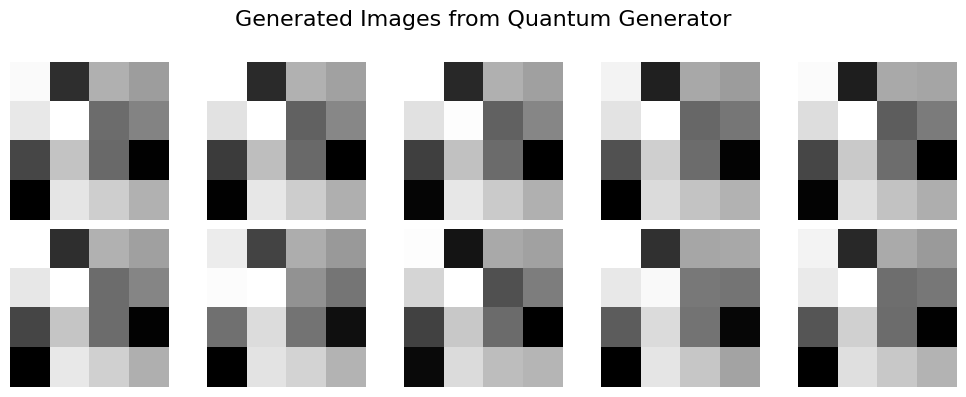

In [ ]:
import matplotlib.pyplot as plt
import torch

# Set number of samples to generate
num_samples = 10

# Set figure size and layout
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
fig.suptitle("Generated Images from Quantum Generator", fontsize=16)

for i in range(num_samples):
    # Generate random noise
    z = torch.randn(1, n_qubits)

    # Generate fake image
    with torch.no_grad():
        gen_out = G(z)

    # Reshape to 4x4 "image"
    fake_img = gen_out.view(4, 4, 1).repeat(1, 1, 1).reshape(1, 4, 4).squeeze()

    # Plot the image
    ax = axes[i // 5][i % 5]
    ax.imshow(fake_img.detach().numpy(), cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()


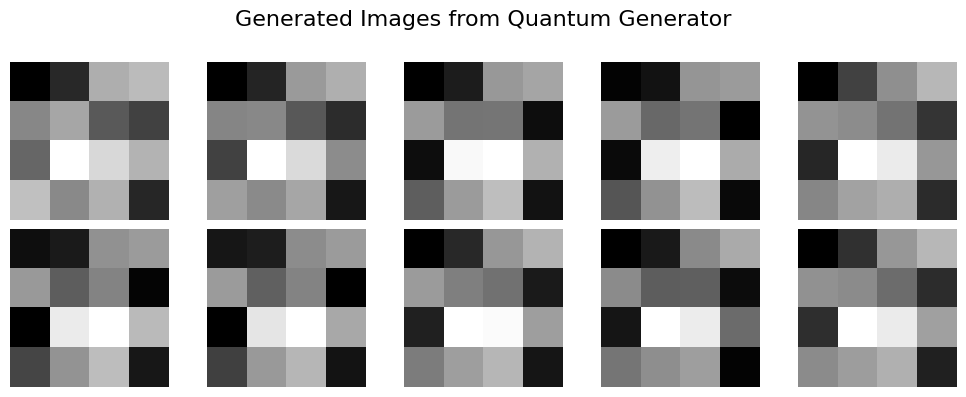

In [ ]:
import matplotlib.pyplot as plt
import torch

# Set number of samples to generate
num_samples = 10

# Set figure size and layout
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
fig.suptitle("Generated Images from Quantum Generator", fontsize=16)

for i in range(num_samples):
    # Generate random noise
    z = torch.randn(1, 16)

    # Generate fake image
    with torch.no_grad():
        gen_out = G(z)

    # Reshape to 4x4 "image"
    fake_img = gen_out.view(4, 4,).cpu()

    # Plot the image
    ax = axes[i // 5][i % 5]
    ax.imshow(fake_img, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

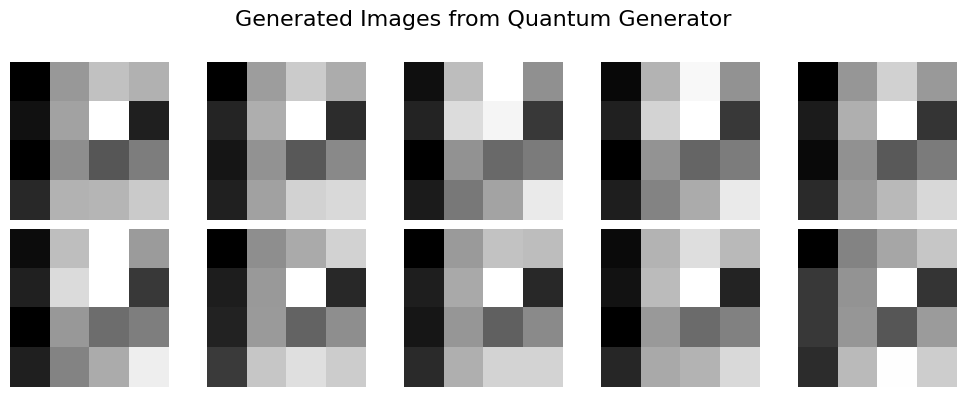

In [14]:
import matplotlib.pyplot as plt
import torch

# Set number of samples to generate
num_samples = 10

# Set figure size and layout
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
fig.suptitle("Generated Images from Quantum Generator", fontsize=16)

for i in range(num_samples):
    # Generate random noise
    z = torch.randn(1, 16, device=z.device)

    # Generate fake image
    with torch.no_grad():
        gen_out = G(z)

    # Reshape to 4x4 "image"
    fake_img = gen_out.view(4, 4,).cpu()

    # Plot the image
    ax = axes[i // 5][i % 5]
    ax.imshow(fake_img, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

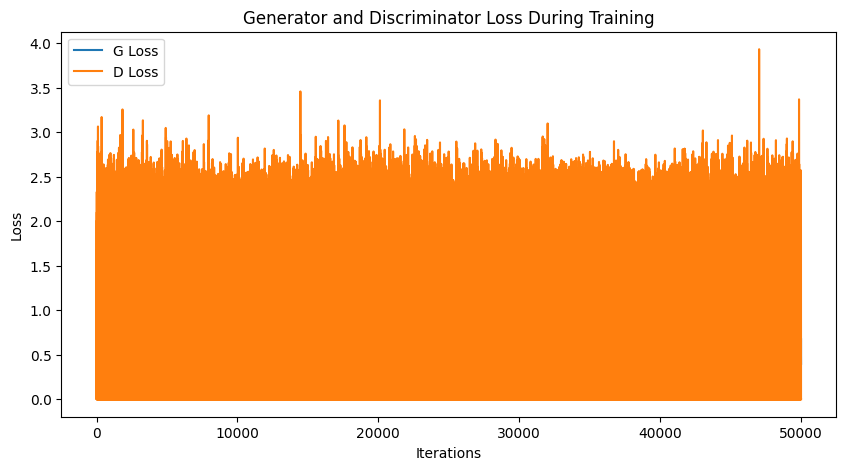

In [ ]:
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="G Loss")
plt.plot(D_losses, label="D Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

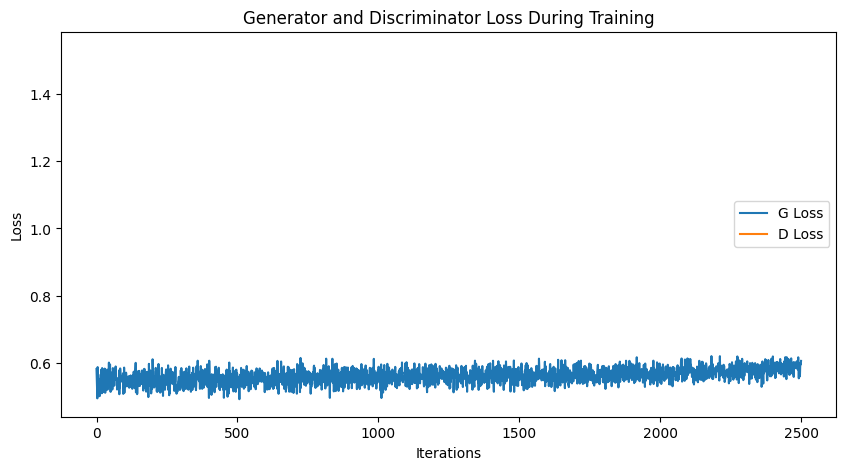

In [ ]:
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="G Loss")
plt.plot(D_losses, label="D Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

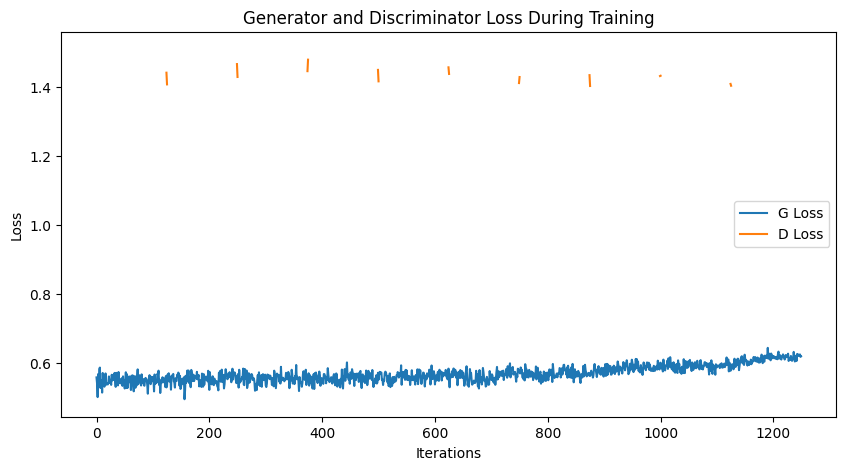

In [15]:
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="G Loss")
plt.plot(D_losses, label="D Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()